# ChatGPT code

Saved: ode_models_overview.png


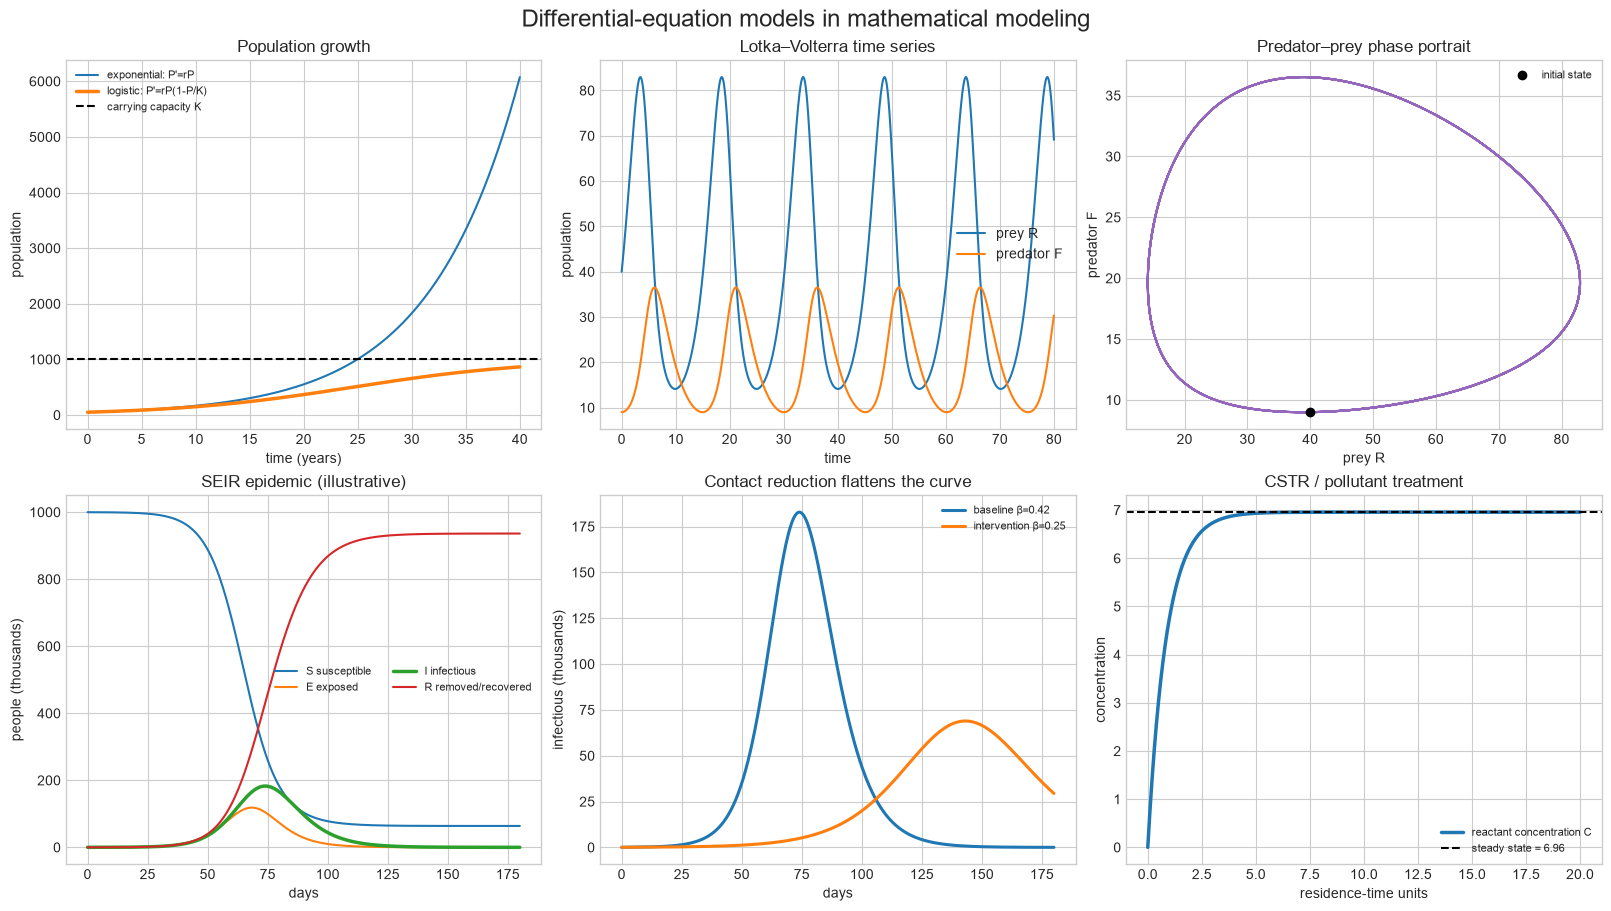

In [2]:
# 常见微分方程模型：人口、食饵-捕食者、传染病与其他应用。

# 运行：python ode_modeling_examples.py
# 会在当前目录写出 ode_models_overview.png。
# 依赖：numpy, scipy, matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


plt.style.use("seaborn-v0_8-whitegrid")


def solve(rhs, t, y0, args=()):
    """以指定时间网格求解常微分方程。"""
    return solve_ivp(rhs, (t[0], t[-1]), y0, t_eval=t, args=args,
                     rtol=1e-8, atol=1e-10).y


def logistic(t, y, r, K):
    # y'=r*y*(1-y/K)：资源有限时的人口增长
    return [r * y[0] * (1 - y[0] / K)]


def lotka_volterra(t, y, a, b, c, d):
    # R: 食饵，F: 捕食者；R'=aR-bRF，F'=dRF-cF
    R, F = y
    return [a * R - b * R * F, d * R * F - c * F]


def seir(t, y, beta, sigma, gamma, n):
    # S易感、E潜伏、I感染、R移除；人口总数 n 保持不变
    S, E, I, R = y
    force = beta * S * I / n
    return [-force, force - sigma * E, sigma * E - gamma * I, gamma * I]


def cstr(t, y, q_over_v, cin, k):
    # 连续搅拌反应器：流入-流出 + 一阶反应消耗
    C = y[0]
    return [q_over_v * (cin - C) - k * C]


def main():
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    fig.suptitle("Differential-equation models in mathematical modeling", fontsize=17)

    # 1. 指数增长与逻辑斯蒂增长
    t = np.linspace(0, 40, 401)
    p0, r, K = 50, 0.12, 1000
    exponential = p0 * np.exp(r * t)
    population = solve(logistic, t, [p0], (r, K))[0]
    ax = axes[0, 0]
    ax.plot(t, exponential, label="exponential: P'=rP")
    ax.plot(t, population, linewidth=2.5, label="logistic: P'=rP(1-P/K)")
    ax.axhline(K, color="black", linestyle="--", label="carrying capacity K")
    ax.set(title="Population growth", xlabel="time (years)", ylabel="population")
    ax.legend(fontsize=8)

    # 2. 食饵—捕食者
    t = np.linspace(0, 80, 1601)
    prey, predator = solve(lotka_volterra, t, [40, 9], (0.55, 0.028, 0.35, 0.009))
    ax = axes[0, 1]
    ax.plot(t, prey, label="prey R")
    ax.plot(t, predator, label="predator F")
    ax.set(title="Lotka–Volterra time series", xlabel="time", ylabel="population")
    ax.legend()
    ax = axes[0, 2]
    ax.plot(prey, predator, color="tab:purple")
    ax.scatter(prey[0], predator[0], color="black", zorder=3, label="initial state")
    ax.set(title="Predator–prey phase portrait", xlabel="prey R", ylabel="predator F")
    ax.legend(fontsize=8)

    # 3. SEIR：一个新冠式呼吸道传染病示例（假设参数，并非真实拟合）
    # beta=0.42/day, 潜伏期 1/sigma=4 天, 传染期 1/gamma=7 天
    t = np.linspace(0, 180, 721)
    n = 1_000_000
    S, E, I, R = solve(seir, t, [n - 120, 80, 40, 0], (0.42, 1 / 4, 1 / 7, n))
    ax = axes[1, 0]
    ax.plot(t, S / 1000, label="S susceptible")
    ax.plot(t, E / 1000, label="E exposed")
    ax.plot(t, I / 1000, linewidth=2.5, label="I infectious")
    ax.plot(t, R / 1000, label="R removed/recovered")
    ax.set(title="SEIR epidemic (illustrative)", xlabel="days", ylabel="people (thousands)")
    ax.legend(fontsize=8, ncol=2)

    # 4. 干预比较：改变 beta（接触率）即可看到峰值差异
    ax = axes[1, 1]
    for beta, label in [(0.42, "baseline β=0.42"), (0.25, "intervention β=0.25")]:
        infected = solve(seir, t, [n - 120, 80, 40, 0], (beta, 1 / 4, 1 / 7, n))[2]
        ax.plot(t, infected / 1000, linewidth=2.2, label=label)
    ax.set(title="Contact reduction flattens the curve", xlabel="days", ylabel="infectious (thousands)")
    ax.legend(fontsize=8)

    # 5. 工程/环境：连续搅拌反应器浓度趋于平衡
    t = np.linspace(0, 20, 401)
    C = solve(cstr, t, [0], (0.8, 10, 0.35))[0]
    steady = 0.8 * 10 / (0.8 + 0.35)
    ax = axes[1, 2]
    ax.plot(t, C, linewidth=2.5, label="reactant concentration C")
    ax.axhline(steady, color="black", linestyle="--", label=f"steady state = {steady:.2f}")
    ax.set(title="CSTR / pollutant treatment", xlabel="residence-time units", ylabel="concentration")
    ax.legend(fontsize=8)

    fig.savefig("ode_models_overview.png", dpi=180, bbox_inches="tight")
    print("Saved: ode_models_overview.png")


if __name__ == "__main__":
    main()

In [1]:
from math import exp


def rk4(f, y0, t_end, dt):
    ts, ys, t, y = [0.0], [list(y0)], 0.0, list(y0)
    while t < t_end - 1e-12:
        h = min(dt, t_end - t)
        k1 = f(t, y)
        k2 = f(t + h / 2, [v + h * q / 2 for v, q in zip(y, k1)])
        k3 = f(t + h / 2, [v + h * q / 2 for v, q in zip(y, k2)])
        k4 = f(t + h, [v + h * q for v, q in zip(y, k3)])
        y = [v + h * (a + 2*b + 2*c + d) / 6 for v, a, b, c, d in zip(y, k1, k2, k3, k4)]
        t += h; ts.append(t); ys.append(list(y))
    return ts, list(zip(*ys))


def polyline(xs, ys, box, xmax, ymax, color, width=2):
    x, y, w, h = box
    pts = " ".join(f"{x+w*u/xmax:.1f},{y+h-h*v/ymax:.1f}" for u, v in zip(xs, ys))
    return f'<polyline points="{pts}" fill="none" stroke="{color}" stroke-width="{width}"/>'


def panel(title, box, xmax, ymax, series, xlab="time", ylab="population"):
    x, y, w, h = box
    out = [f'<rect x="{x}" y="{y}" width="{w}" height="{h}" class="box"/>',
           f'<text x="{x+w/2}" y="{y-12}" text-anchor="middle" class="title">{title}</text>',
           f'<text x="{x+w/2}" y="{y+h+35}" text-anchor="middle">{xlab}</text>',
           f'<text x="{x-38}" y="{y+h/2}" text-anchor="middle" transform="rotate(-90 {x-38} {y+h/2})">{ylab}</text>',
           f'<text x="{x}" y="{y+h+15}" class="tiny">0</text>', f'<text x="{x+w-10}" y="{y+h+15}" class="tiny">{xmax:g}</text>',
           f'<text x="{x-28}" y="{y+h}" class="tiny">0</text>', f'<text x="{x-38}" y="{y+5}" class="tiny">{ymax:g}</text>']
    for i, (name, xs, ys, color) in enumerate(series):
        out.append(polyline(xs, ys, box, xmax, ymax, color))
        out.append(f'<text x="{x+8}" y="{y+17+i*16}" fill="{color}" class="legend">— {name}</text>')
    return "\n".join(out)


def main():
    # 人口：P'=rP(1-P/K)
    t1 = [i/10 for i in range(401)]; r, K, p0 = .12, 1000, 50
    logistic = [K / (1 + (K/p0-1)*exp(-r*t)) for t in t1]
    exponential = [p0*exp(r*t) for t in t1]
    # 食饵-捕食者：R'=aR-bRF, F'=dRF-cF
    t2, (prey, predator) = rk4(lambda t, y: [.55*y[0]-.028*y[0]*y[1], .009*y[0]*y[1]-.35*y[1]], [40, 9], 80, .05)
    # SEIR：百万人的假想呼吸道传染病；非真实新冠数据拟合
    n, beta, sigma, gamma = 1_000_000, .42, 1/4, 1/7
    def seir(t, y):
        s,e,i,rr=y; new=beta*s*i/n
        return [-new, new-sigma*e, sigma*e-gamma*i, gamma*i]
    t3, (s,e,i,rr) = rk4(seir, [n-120,80,40,0], 180, .25)
    def seir_i(beta):
        def f(t,y):
            s,e,i,rr=y; new=beta*s*i/n
            return [-new,new-sigma*e,sigma*e-gamma*i,gamma*i]
        return rk4(f, [n-120,80,40,0], 180, .25)
    _, (_,_,i_intervention,_) = seir_i(.25)

    svg = ['<svg xmlns="http://www.w3.org/2000/svg" width="1200" height="770" viewBox="0 0 1200 770">',
           '<style>text{font-family:Arial,sans-serif;font-size:13px}.title{font-size:16px;font-weight:bold}.legend{font-size:12px}.tiny{font-size:10px}.box{fill:#fff;stroke:#889;stroke-width:1}</style>',
           '<rect width="1200" height="770" fill="#f6f8fb"/><text x="600" y="32" text-anchor="middle" style="font-size:22px;font-weight:bold">常见微分方程模型：数值模拟结果</text>']
    svg += [panel("人口增长：指数 vs. 逻辑斯蒂", (85,80,470,250), 40, 6000,
                  [("指数增长",t1,exponential,"#d55e00"),("逻辑斯蒂增长",t1,logistic,"#0072b2")], "年", "人口"),
            panel("Lotka–Volterra 食饵—捕食者", (670,80,470,250), 80, 70,
                  [("食饵 R",t2,prey,"#009e73"),("捕食者 F",t2,predator,"#cc79a7")], "时间", "种群数量"),
            panel("SEIR：传染病传播（假设参数）", (85,455,470,250), 180, 1000,
                  [("S 易感",t3,[v/1000 for v in s],"#0072b2"),("E 潜伏",t3,[v/1000 for v in e],"#e69f00"),("I 感染",t3,[v/1000 for v in i],"#d55e00"),("R 康复/移除",t3,[v/1000 for v in rr],"#009e73")], "天", "人数（千）"),
            panel("降低接触率会压低感染峰值", (670,455,470,250), 180, 300,
                  [("基线 β=0.42",t3,[v/1000 for v in i],"#d55e00"),("干预 β=0.25",t3,[v/1000 for v in i_intervention],"#0072b2")], "天", "感染者（千）")]
    svg.append('</svg>')
    with open("ode_models_overview.svg", "w", encoding="utf-8") as f: f.write("\n".join(svg))
    print("Saved: ode_models_overview.svg")


if __name__ == "__main__": main()

Saved: ode_models_overview.svg


e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27987 (\N{CJK UNIFIED IDEOGRAPH-6D53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 33647 (\N{CJK UNIFIED IDEOGRAPH-836F}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

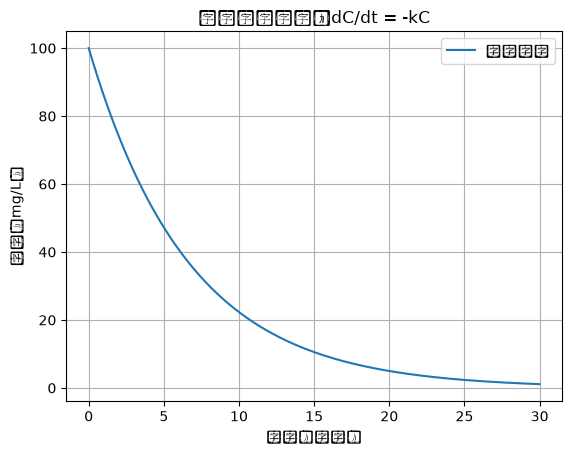

In [5]:
import numpy as np
import matplotlib.pyplot as plt

C0 = 100       # 初始浓度，mg/L
k = 0.15       # 代谢速率，1/小时
t = np.linspace(0, 30, 300)

C = C0 * np.exp(-k * t)

plt.plot(t, C, label="药物浓度")
plt.xlabel("时间（小时）")
plt.ylabel("浓度（mg/L）")
plt.title("药物代谢模型：dC/dt = -kC")
plt.grid()
plt.legend()
plt.show()

e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 29275 (\N{CJK UNIFIED IDEOGRAPH-725B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 39039 (\N{CJK UNIFIED IDEOGRAPH-987F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21364 (\N{CJK UNIFIED IDEOGRAPH-5374}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

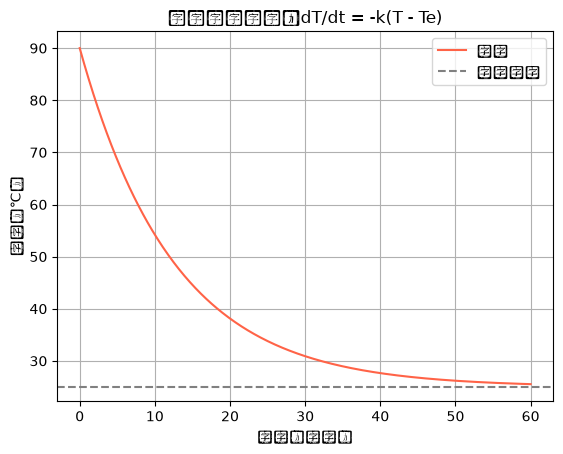

In [6]:
import numpy as np
import matplotlib.pyplot as plt

T0 = 90        # 热水初温，摄氏度
Te = 25        # 室温，摄氏度
k = 0.08       # 冷却系数
t = np.linspace(0, 60, 500)

T = Te + (T0 - Te) * np.exp(-k * t)

plt.plot(t, T, color="tomato", label="水温")
plt.axhline(Te, color="gray", linestyle="--", label="环境温度")
plt.xlabel("时间（分钟）")
plt.ylabel("温度（℃）")
plt.title("牛顿冷却定律：dT/dt = -k(T - Te)")
plt.grid()
plt.legend()
plt.show()

e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36830 (\N{CJK UNIFIED IDEOGRAPH-8FDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32493 (\N{CJK UNIFIED IDEOGRAPH-7EED}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

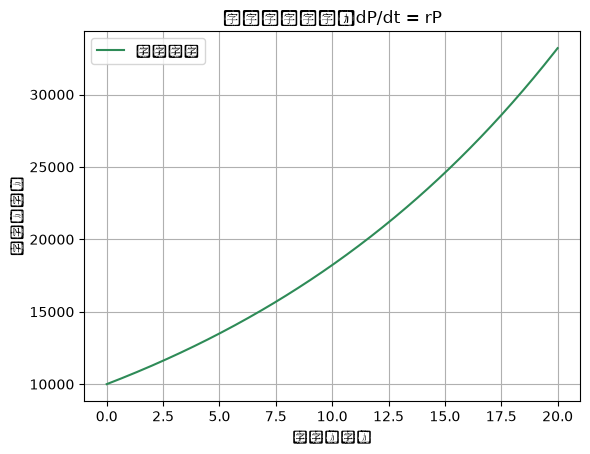

20 年后的资产约为：33201.17 元


In [7]:
import numpy as np
import matplotlib.pyplot as plt

P0 = 10000     # 初始本金，元
r = 0.06       # 年连续增长率 6%
t = np.linspace(0, 20, 300)

P = P0 * np.exp(r * t)

plt.plot(t, P, color="seagreen", label="资产规模")
plt.xlabel("时间（年）")
plt.ylabel("资产（元）")
plt.title("连续复利模型：dP/dt = rP")
plt.grid()
plt.legend()
plt.show()

print(f"20 年后的资产约为：{P[-1]:.2f} 元")

e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 38459 (\N{CJK UNIFIED IDEOGRAPH-963B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23612 (\N{CJK UNIFIED IDEOGRAPH-5C3C}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

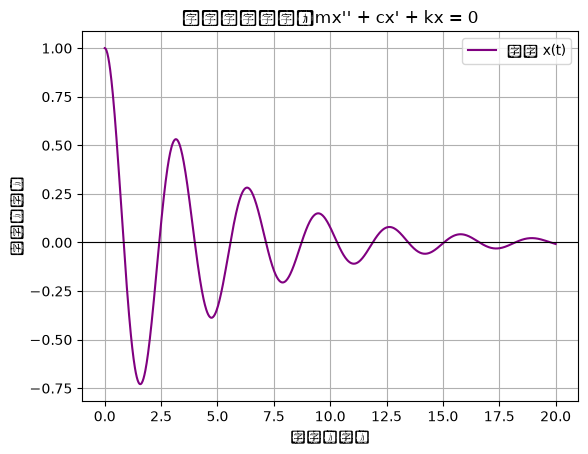

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 参数
m = 1.0      # 质量，kg
c = 0.4      # 阻尼系数
k = 4.0      # 弹簧刚度，N/m

# 方程组：y[0] = x，y[1] = v
def vibration(t, y):
    x, v = y
    dxdt = v
    dvdt = -(c / m) * v - (k / m) * x
    return [dxdt, dvdt]

# 初始条件：初始位移 1 m，初速度 0
y0 = [1.0, 0.0]

t_eval = np.linspace(0, 20, 1000)
solution = solve_ivp(
    vibration,
    t_span=(0, 20),
    y0=y0,
    t_eval=t_eval
)

t = solution.t
x = solution.y[0]

plt.plot(t, x, color="purple", label="位移 x(t)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("时间（秒）")
plt.ylabel("位移（米）")
plt.title("阻尼弹簧振动：mx'' + cx' + kx = 0")
plt.grid()
plt.legend()
plt.show()

药物浓度降至 10 mg/L 约需 15.35 小时


e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24494 (\N{CJK UNIFIED IDEOGRAPH-5FAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Code\Python\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

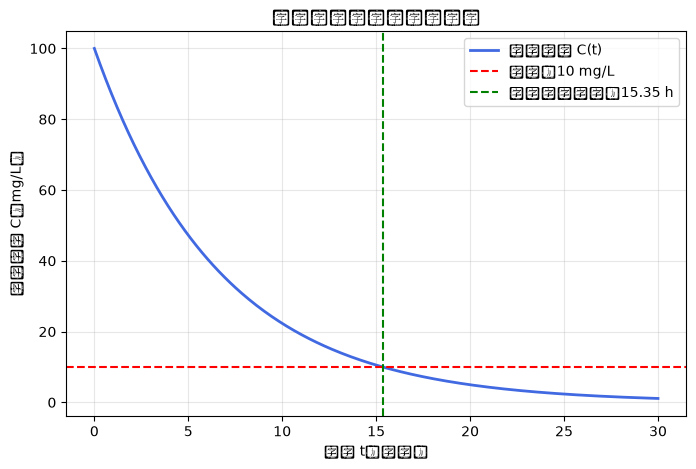

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
C0 = 100       # 初始药物浓度，mg/L
k = 0.15       # 代谢速率常数，1/h
threshold = 10 # 安全阈值，mg/L

# 时间范围：0 到 30 小时
t = np.linspace(0, 30, 300)

# 微分方程解析解：C(t) = C0 * exp(-k*t)
C = C0 * np.exp(-k * t)

# 计算浓度下降至阈值所需时间
t_threshold = np.log(C0 / threshold) / k

print(f"药物浓度降至 {threshold} mg/L 约需 {t_threshold:.2f} 小时")

# 作图
plt.figure(figsize=(8, 5))
plt.plot(t, C, label="药物浓度 C(t)", color="royalblue", linewidth=2)
plt.axhline(threshold, color="red", linestyle="--", label=f"阈值：{threshold} mg/L")
plt.axvline(t_threshold, color="green", linestyle="--",
            label=f"达到阈值时间：{t_threshold:.2f} h")

plt.title("药物代谢的微分方程模型")
plt.xlabel("时间 t（小时）")
plt.ylabel("药物浓度 C（mg/L）")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Gemini Code

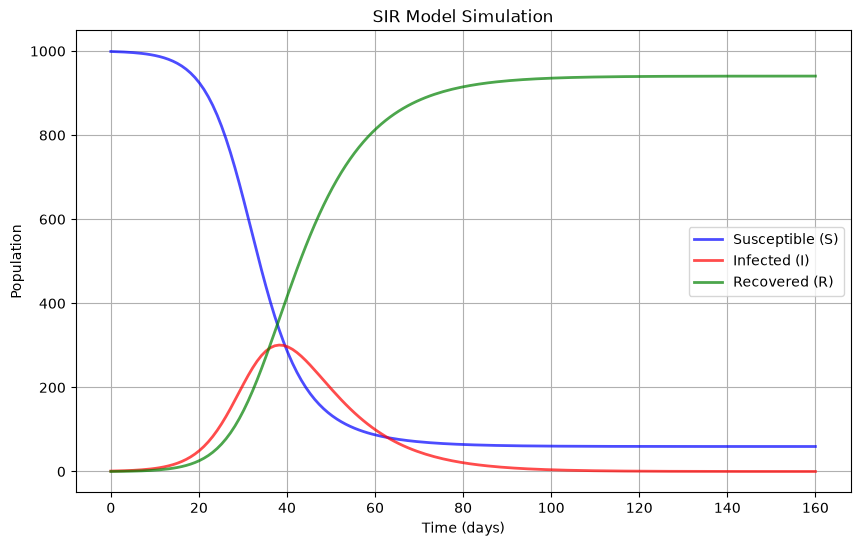

In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. 定义 SIR 微分方程组模型
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# 2. 初始化参数
N = 1000          # 总人口
I0, R0 = 1, 0     # 初始感染者1人，初始恢复者0人
S0 = N - I0 - R0  # 初始易感者
beta = 0.3        # 接触感染率
gamma = 0.1       # 恢复率 (意味着平均10天恢复)

# 初始状态向量
y0 = S0, I0, R0

# 时间网格 (模拟 160 天)
t = np.linspace(0, 160, 160)

# 3. 求解常微分方程
# odeint 需要传入：模型函数, 初始状态, 时间网格, (附加参数)
ret = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = ret.T

# 4. 可视化绘图
plt.figure(figsize=(10, 6))
plt.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible (S)')
plt.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected (I)')
plt.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered (R)')
plt.title('SIR Model Simulation')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.grid(True)
plt.legend()
plt.show()

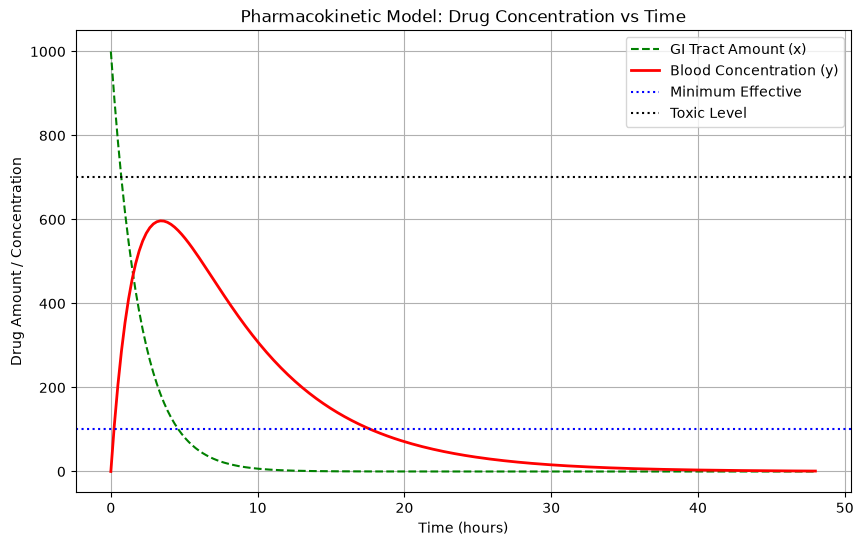

In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. 定义药物动力学模型（微分方程组）
def pharm_model(vars, t, ka, ke):
    x, y = vars
    # dx/dt: 肠胃中药物的减少
    dxdt = -ka * x
    # dy/dt: 血液中药物的增加(吸收) - 减少(消除)
    dydt = ka * x - ke * y
    return [dxdt, dydt]

# 2. 设置参数
# 假设病人服下剂量 D0 = 1000 mg
D0 = 1000
y0 = 0.0     # 初始时血液中没有药物
initial_conditions = [D0, y0]

ka = 0.5     # 吸收率常数 (1/h)
ke = 0.15    # 消除率常数 (1/h)

# 模拟 48 小时的时间变化
t = np.linspace(0, 48, 200)

# 3. 求解微分方程
solution = odeint(pharm_model, initial_conditions, t, args=(ka, ke))
# x 是肠胃药物量，y 是血液药物量
x = solution[:, 0]
y = solution[:, 1]

# 4. 可视化
plt.figure(figsize=(10, 6))
plt.plot(t, x, 'g--', label='GI Tract Amount (x)')
plt.plot(t, y, 'r-', linewidth=2, label='Blood Concentration (y)')

# 假设有效浓度区间（治疗窗）
plt.axhline(y=100, color='b', linestyle=':', label='Minimum Effective')
plt.axhline(y=700, color='k', linestyle=':', label='Toxic Level')

plt.title('Pharmacokinetic Model: Drug Concentration vs Time')
plt.xlabel('Time (hours)')
plt.ylabel('Drug Amount / Concentration')
plt.legend()
plt.grid(True)
plt.show()